# Comparison of Placement Algorithms

This notebook compares the performance metrics (latency and network usage) between two YAFS placement algorithms:
1. **Latency-based (Baseline)**
2. **Custom Proposed Strategy**

The analysis uses simulation trace data generated by YAFS.

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [167]:
# Define file paths
results_dir = 'resultados'

# Latency Strategy Files
latency_trace_file = os.path.join(results_dir, '5-latency-sim_trace.csv')
latency_link_file = os.path.join(results_dir, '5-latency-sim_trace_link.csv')

# Custom Strategy Files
custom_trace_file = os.path.join(results_dir, '5-custom_proposed_by_felipe-sim_trace.csv')
custom_link_file = os.path.join(results_dir, '5-custom_proposed_by_felipe-sim_trace_link.csv')

# Round Robin Strategy Files
rr_trace_file = os.path.join(results_dir, '5-roundRobin-sim_trace.csv')
rr_link_file = os.path.join(results_dir, '5-roundRobin-sim_trace_link.csv')

# Load DataFrames
df_latency_trace = pd.read_csv(latency_trace_file)
df_latency_link = pd.read_csv(latency_link_file)

df_custom_trace = pd.read_csv(custom_trace_file)
df_custom_link = pd.read_csv(custom_link_file)

df_rr_trace = pd.read_csv(rr_trace_file)
df_rr_link = pd.read_csv(rr_link_file)

print("Data loaded successfully.")
print(f"Latency Trace: {df_latency_trace.shape}")
print(f"Custom Trace: {df_custom_trace.shape}")
print(f"Round Robin Trace: {df_rr_trace.shape}")

Data loaded successfully.
Latency Trace: (1068, 17)
Custom Trace: (354, 17)
Round Robin Trace: (1487, 17)


In [168]:
# Add Strategy Label
df_latency_trace['Strategy'] = 'Latency (Baseline)'
df_custom_trace['Strategy'] = 'Custom Proposed'
df_rr_trace['Strategy'] = 'Round Robin'

df_latency_link['Strategy'] = 'Latency (Baseline)'
df_custom_link['Strategy'] = 'Custom Proposed'
df_rr_link['Strategy'] = 'Round Robin'

# Combine DataFrames
df_trace_all = pd.concat([df_latency_trace, df_custom_trace, df_rr_trace])
df_link_all = pd.concat([df_latency_link, df_custom_link, df_rr_link])

# Filter for End-to-End Latency (Service -> Sensor Response)
# The application flow is Sensor -> Service (M_Req) -> Sensor (M_Resp).
# We analyze the latency of the response message 'M_Resp' as it completes the cycle.
# target_message = 'M_Resp'
df_results = df_trace_all #[df_trace_all['message'] == target_message].copy()

if df_results.empty:
    print(f"WARNING: No messages found with name '{target_message}'. Check your simulation code.")
else:
    # Calculate Latency
    df_results['latency'] = df_results['service']

    print("Combined Data:")
    print(df_results[['Strategy', 'latency']].head())

Combined Data:
             Strategy   latency
0  Latency (Baseline)  0.002356
1  Latency (Baseline)  0.001789
2  Latency (Baseline)  0.000962
3  Latency (Baseline)  0.001127
4  Latency (Baseline)  0.001120


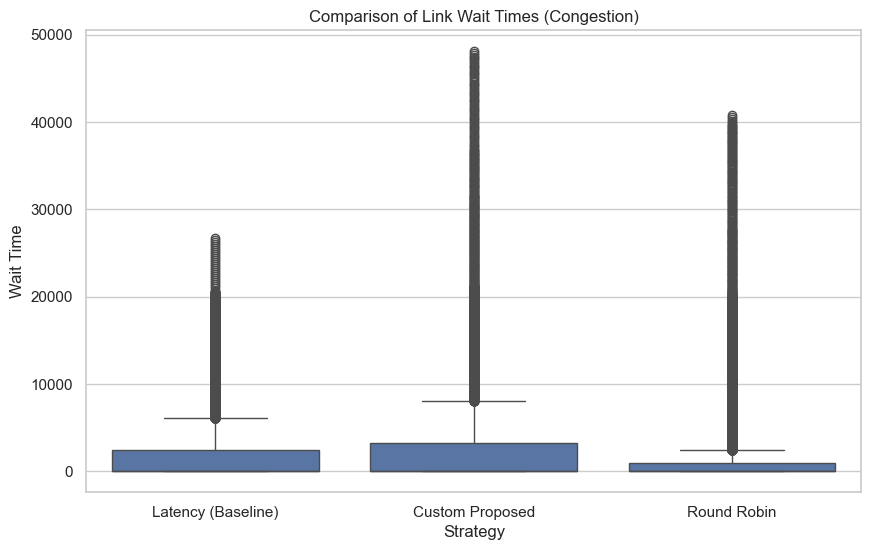

Link Wait Time Statistics:


,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
Custom Proposed,37776.0,2473.978011,4874.132125,0.0,0.0,0.0,3224.700985,48109.185340
Latency (Baseline),44662.0,1936.154294,3660.532325,0.0,0.0,0.0,2433.653472,26739.548961
Round Robin,46766.0,1475.388963,3564.412596,0.0,0.0,0.0,977.435730,40783.443626


In [169]:
# Compare Link Wait Times
if 'wait' in df_link_all.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Strategy', y='wait', data=df_link_all)
    plt.title('Comparison of Link Wait Times (Congestion)')
    plt.ylabel('Wait Time')
    plt.show()
    
    # Summary stats for wait time
    print("Link Wait Time Statistics:")
    display(df_link_all.groupby('Strategy')['wait'].describe())
else:
    print("Wait time column not found in link traces.")

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_1641/173178218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")


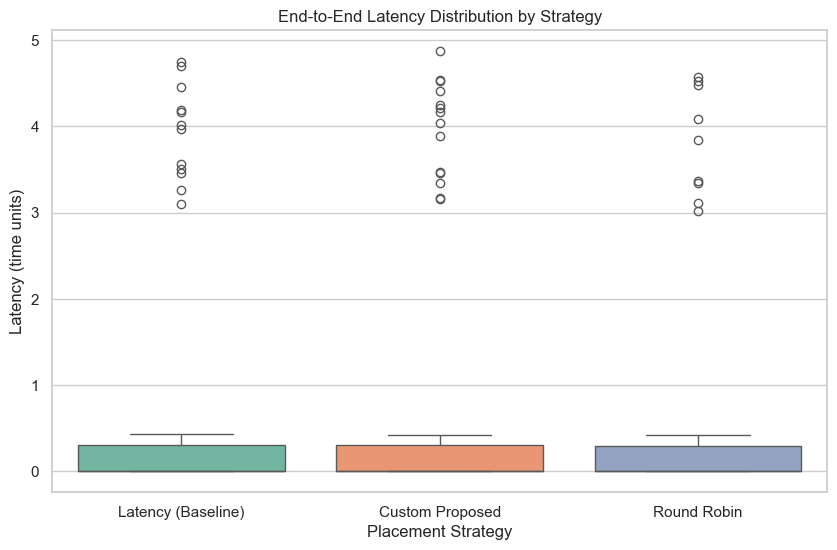

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_1641/173178218.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")


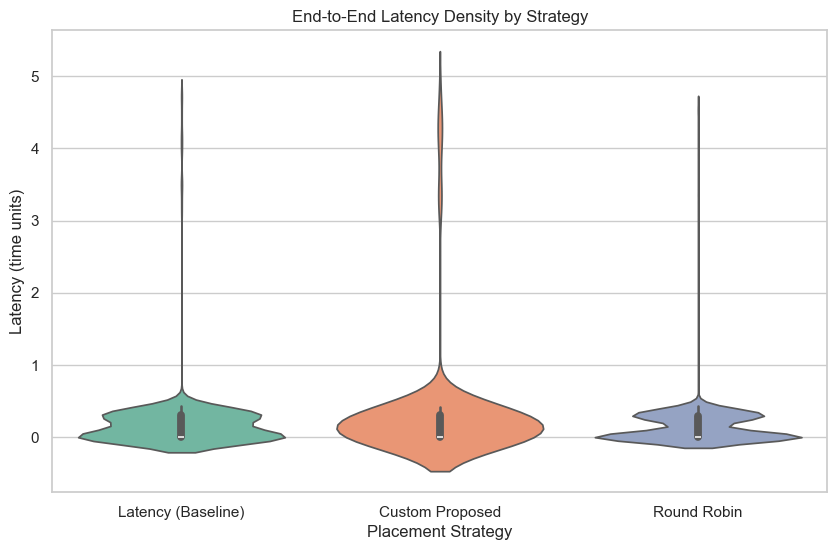

In [170]:
# Visualize Latency Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title('End-to-End Latency Distribution by Strategy')
plt.ylabel('Latency (time units)')
plt.xlabel('Placement Strategy')
plt.show()

# Violin Plot for density
plt.figure(figsize=(10, 6))
sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title('End-to-End Latency Density by Strategy')
plt.ylabel('Latency (time units)')
plt.xlabel('Placement Strategy')
plt.show()

             Strategy  Total Bytes Transferred
0     Custom Proposed                 37501203
1  Latency (Baseline)                 43820870
2         Round Robin                 45511664


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_1641/2933405023.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Total Bytes Transferred', data=network_usage, palette="viridis")


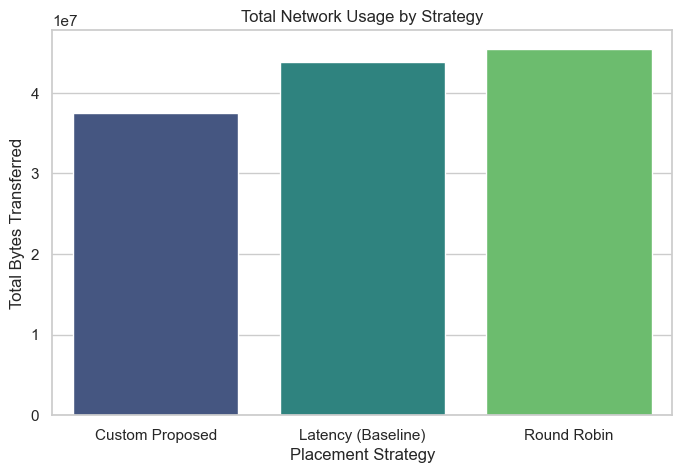

In [171]:
# Calculate Total Network Usage (Bytes Transferred)
network_usage = df_link_all.groupby('Strategy')['size'].sum().reset_index()
network_usage.columns = ['Strategy', 'Total Bytes Transferred']

print(network_usage)

# Visualize Network Usage
plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Total Bytes Transferred', data=network_usage, palette="viridis")
plt.title('Total Network Usage by Strategy')
plt.ylabel('Total Bytes Transferred')
plt.xlabel('Placement Strategy')
plt.show()

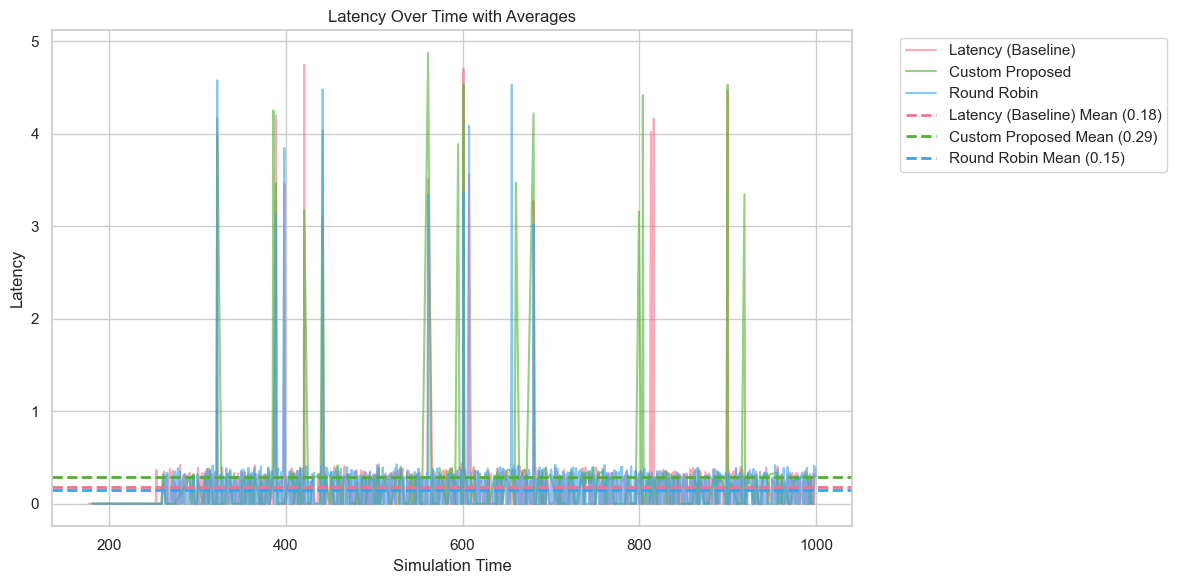

In [172]:
# Latency Over Time with Averages
plt.figure(figsize=(12, 6))

# Define a palette to ensure consistent colors
strategies = df_results['Strategy'].unique()
palette = sns.color_palette("husl", len(strategies))
strategy_colors = dict(zip(strategies, palette))

# Plot Latency over Time
sns.lineplot(x='time_reception', y='latency', hue='Strategy', data=df_results, alpha=0.6, palette=strategy_colors)

# Calculate and plot averages
for strategy in strategies:
    mean_val = df_results[df_results['Strategy'] == strategy]['latency'].mean()
    color = strategy_colors[strategy]
    plt.axhline(y=mean_val, color=color, linestyle='--', linewidth=2, label=f'{strategy} Mean ({mean_val:.2f})')

plt.title('Latency Over Time with Averages')
plt.xlabel('Simulation Time')
plt.ylabel('Latency')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [173]:
# Summary Statistics
summary_stats = df_results.groupby('Strategy')['latency'].agg(['mean', 'min', 'max', 'std', 'count']).reset_index()
summary_stats = summary_stats.merge(network_usage, on='Strategy')

print("Summary Statistics Table:")
display(summary_stats)

Summary Statistics Table:


,Strategy,mean,min,max,std,count,Total Bytes Transferred
0,Custom Proposed,0.293038,0.000774,4.872322,0.768903,354,37501203
1,Latency (Baseline),0.181978,0.000765,4.743859,0.431450,1068,43820870
2,Round Robin,0.153639,0.000765,4.576744,0.327481,1487,45511664


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_1641/3521826341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Delivered Messages', data=message_counts, palette="magma")


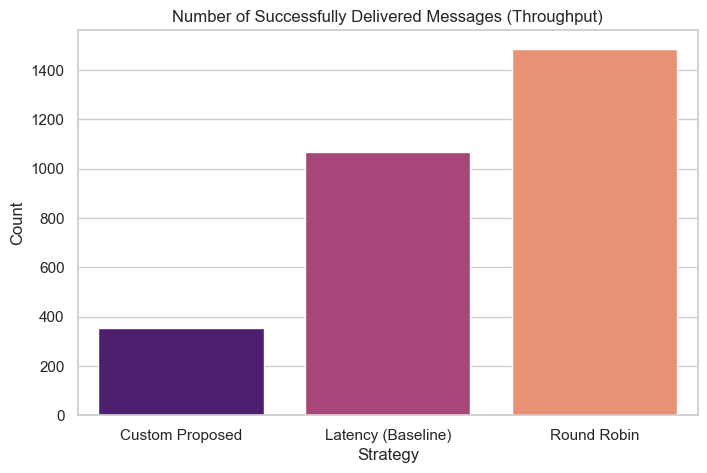

Message Delivery Counts:


,Strategy,Delivered Messages
0,Custom Proposed,354
1,Latency (Baseline),1068
2,Round Robin,1487


In [174]:
# Visualize Message Delivery Count (Throughput)
message_counts = df_results.groupby('Strategy').size().reset_index(name='Delivered Messages')

plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Delivered Messages', data=message_counts, palette="magma")
plt.title('Number of Successfully Delivered Messages (Throughput)')
plt.ylabel('Count')
plt.show()

print("Message Delivery Counts:")
display(message_counts)


### Why are the Latency results equal?

If the "Latency Over Time" graph shows identical or overlapping lines for both strategies, it is likely due to two factors:

1.  **Identical Optimal Path**: The `Custom` strategy uses a scoring system where **Latency has a high weight (80%)**. Combined with the `MinimunPath` selection policy (which picks the closest service instance), the traffic is routed to the same "best" node as in the `Latency` (Baseline) strategy. Even though `Custom` deploys a second replica (on a different ISP), the selection policy ignores it if it is further away.
2.  **Survivorship Bias (Packet Loss)**: The `Custom` strategy may be causing congestion (due to the overhead of managing multiple replicas or resource contention), resulting in **packet loss**. The simulation trace only records *successfully delivered* messages. Messages that are stuck in queues (high latency) are not present in the CSV. Therefore, the graph only shows the "survivors" — the messages that took the optimal path and didn't get stuck. These survivors have the same latency as the baseline.

**Conclusion**: The `Custom` strategy is performing **worse** in terms of reliability/throughput (fewer messages delivered), but the messages that *do* arrive have the same latency as the baseline.
